## 13장 과적합 피하기

### 초음파 광물 예제 ( sonar.csv )

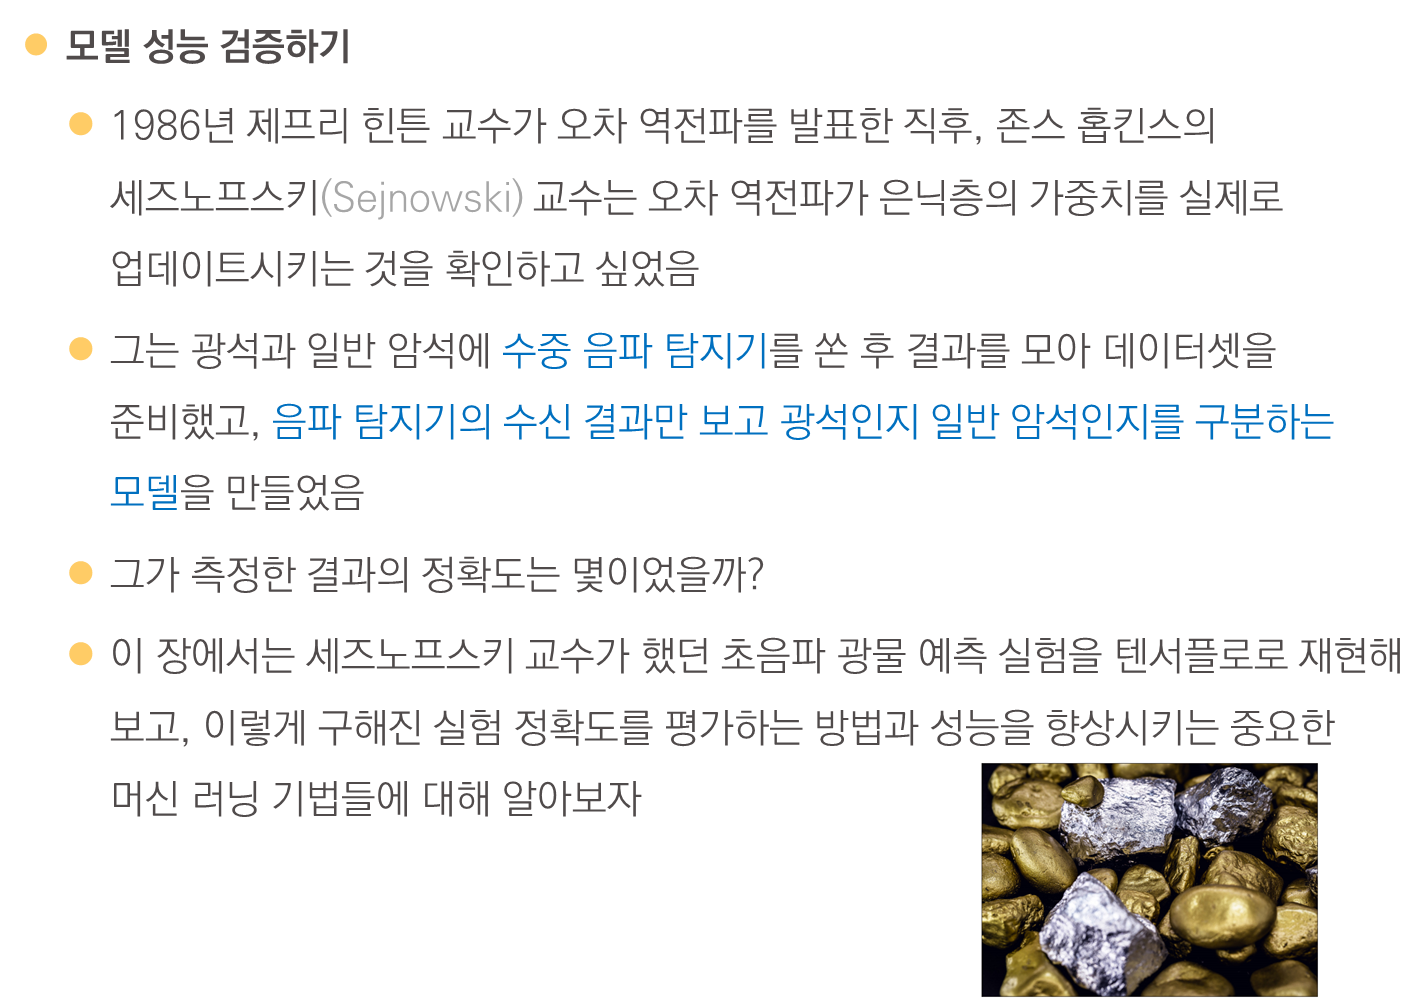

In [2]:
import pandas as pd

df_sonar = pd.read_csv('./data/sonar.csv', header=None)   # 컬럼명 없음
df_sonar

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157,M
204,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067,M
205,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031,M
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,M


In [3]:
df_sonar.iloc[:, -1]     # M :  광석(Mineral),  R : 일반 암석(Regular)

0      R
1      R
2      R
3      R
4      R
      ..
203    M
204    M
205    M
206    M
207    M
Name: 60, Length: 208, dtype: object

In [4]:
## 각 클래스별 데이터 건수 확인
df_sonar.iloc[:, -1].value_counts()

60
M    111
R     97
Name: count, dtype: int64

<Axes: xlabel='60'>

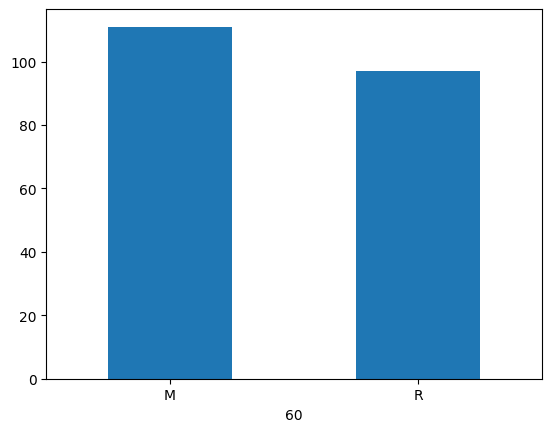

In [5]:
## 클래스 분포 시각화
df_sonar.iloc[:, -1].value_counts().plot(kind='bar', rot=0)

In [6]:
########################################################
# 13-1 과적합 피하기 - 초음파광물 (sonar)
########################################################
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import tensorflow as tf

# 데이터 Read
df_sonar = pd.read_csv('./data/sonar.csv', header=None) # 첫번째 줄이 header가 안되도록
X = df_sonar.iloc[:, :-1].values
print("X.dtype:", X.dtype)  # float type인지 확인 필요 -> 아니면 X = X.astype(float) 필요
X.shape

X.dtype: float64


(208, 60)

In [7]:
Y = df_sonar.iloc[:, -1].values
X, Y

(array([[0.02  , 0.0371, 0.0428, ..., 0.0084, 0.009 , 0.0032],
        [0.0453, 0.0523, 0.0843, ..., 0.0049, 0.0052, 0.0044],
        [0.0262, 0.0582, 0.1099, ..., 0.0164, 0.0095, 0.0078],
        ...,
        [0.0522, 0.0437, 0.018 , ..., 0.0138, 0.0077, 0.0031],
        [0.0303, 0.0353, 0.049 , ..., 0.0079, 0.0036, 0.0048],
        [0.026 , 0.0363, 0.0136, ..., 0.0036, 0.0061, 0.0115]]),
 array(['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R',
        'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R',
        'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R',
        'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R',
        'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R',
        'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R',
        'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R',
        'R', 'R', 'R', 'R', 'R', 'R', 'M', 'M', 'M', 'M', 'M', 'M', 'M',
        'M', 'M', 'M', 

In [8]:
# 문자열 -> 정수 인코딩
e = LabelEncoder()
e.fit(Y)
Y_encoded = e.transform(Y)
Y_encoded, e.classes_  # M : 0 광석(Mineral), R: 1 일반암석(Regular)

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array(['M', 'R'], dtype=object))

In [ ]:
X.shape

In [9]:
# 모델 설정
model = Sequential()
model.add(Dense(120, input_dim=60, activation='relu'))
model.add(Dense(100, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # 2진 분류 (0 / 1)

# 모델 컴파일 
model.compile(loss='binary_crossentropy',  # 2진 분류에서 사용되는 손실함수
              optimizer='adam',
              metrics=['accuracy'])

# 모델 실행
hist = model.fit(X, Y_encoded, epochs=50, batch_size=5)

# 결과 출력 
print("\n Accuracy: %.4f" % (model.evaluate(X, Y_encoded)[1]))

Epoch 1/50
42/42 [==============================] - 2s 8ms/step - loss: 0.6767 - accuracy: 0.5962
Epoch 2/50
42/42 [==============================] - 0s 12ms/step - loss: 0.6009 - accuracy: 0.6971
Epoch 3/50
42/42 [==============================] - 0s 5ms/step - loss: 0.5357 - accuracy: 0.7356
Epoch 4/50
42/42 [==============================] - 0s 4ms/step - loss: 0.4579 - accuracy: 0.7933
Epoch 5/50
42/42 [==============================] - 0s 4ms/step - loss: 0.4543 - accuracy: 0.7740
Epoch 6/50
42/42 [==============================] - 0s 6ms/step - loss: 0.4637 - accuracy: 0.7885
Epoch 7/50
42/42 [==============================] - 0s 4ms/step - loss: 0.3974 - accuracy: 0.8125
Epoch 8/50
42/42 [==============================] - 0s 5ms/step - loss: 0.3935 - accuracy: 0.8173
Epoch 9/50
42/42 [==============================] - 0s 5ms/step - loss: 0.3534 - accuracy: 0.8365
Epoch 10/50
42/42 [==============================] - 0s 8ms/step - loss: 0.3761 - accuracy: 0.8221
Epoch 11/50
42/42 

### 학습 결과 분석

In [10]:
model.evaluate(X, Y_encoded)   # 몇개 맞췄나? [loss, accuracy]

7/7 [==============================] - 0s 4ms/step - loss: 0.0020 - accuracy: 1.0000


[0.001969161443412304, 1.0]

<Axes: >

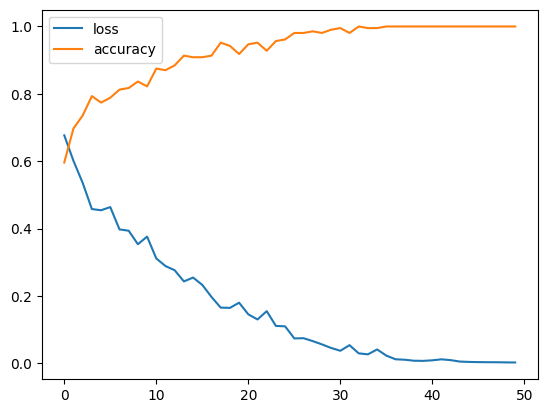

In [11]:
pd.DataFrame(hist.history).plot()  # epoch에 따른 loss, accuracy 변화 그래프

## model.predict로 검증

In [12]:
X[10:50:10].shape  # 4개 X 데이터

(4, 60)

In [13]:
Y_hat = model.predict(X[10:200:50])  # X 데이터로 Y_hat 구해보기
Y_hat.round(3)

1/1 [==============================] - 0s 196ms/step


array([[1.],
       [1.],
       [0.],
       [0.]], dtype=float32)

In [14]:
# 예측 데이터
Y_predicted = (Y_hat > 0.5)
Y_predicted.astype(int)

array([[1],
       [1],
       [0],
       [0]])

In [15]:
# 실제 데이터 (정답)
Y[10:200:50]

array(['R', 'R', 'M', 'M'], dtype=object)

In [16]:
# M, R이었던 Y데이터를 숫자로 인코딩 하였기 때문에 기록을 보면
e.classes_

array(['M', 'R'], dtype=object)

In [17]:
## 2차원 배열을 1차원 배열로 변환, True/False -> 1/0 변환
Y_predicted = Y_predicted.flatten().astype(int)
Y_predicted

array([1, 1, 0, 0])

In [18]:
e.classes_[Y_predicted.flatten().astype(int)]  # 검증 완료!!! (모두 맞춤)

array(['R', 'R', 'M', 'M'], dtype=object)

## 하나의 코드로 정리

Epoch 1/200
42/42 [==============================] - 2s 5ms/step - loss: 0.6795 - accuracy: 0.5577
Epoch 2/200
42/42 [==============================] - 0s 3ms/step - loss: 0.6421 - accuracy: 0.6683
Epoch 3/200
42/42 [==============================] - 0s 2ms/step - loss: 0.5710 - accuracy: 0.7548
Epoch 4/200
42/42 [==============================] - 0s 4ms/step - loss: 0.5251 - accuracy: 0.7404
Epoch 5/200
42/42 [==============================] - 0s 5ms/step - loss: 0.4845 - accuracy: 0.7885
Epoch 6/200
42/42 [==============================] - 0s 4ms/step - loss: 0.4532 - accuracy: 0.7885
Epoch 7/200
42/42 [==============================] - 0s 4ms/step - loss: 0.4139 - accuracy: 0.8077
Epoch 8/200
42/42 [==============================] - 0s 4ms/step - loss: 0.3738 - accuracy: 0.8558
Epoch 9/200
42/42 [==============================] - 0s 3ms/step - loss: 0.3578 - accuracy: 0.8462
Epoch 10/200
42/42 [==============================] - 0s 4ms/step - loss: 0.3517 - accuracy: 0.8221
Epoch 11/

<Axes: >

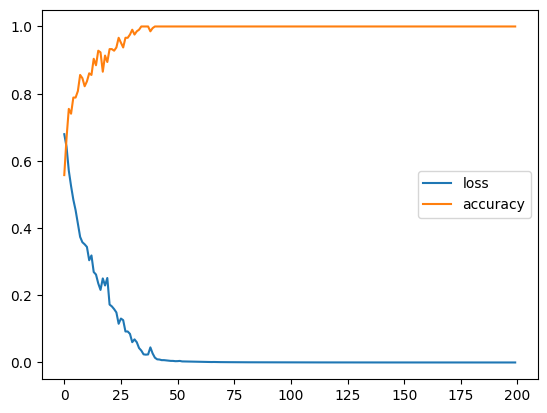

In [19]:
########################################################
# 13-1 과적합 피하기 - 초음파광물 (sonar)
########################################################
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# 데이터 입력
df_sonar = pd.read_csv('./data/sonar.csv', header=None) # 첫번째 줄이 header가 안되도록

X = df_sonar.iloc[:, :-1].values
Y = df_sonar.iloc[:, -1].values

# M->0 초음파 광석(minaral), R->1 일반광물 : 숫자로 인코딩(0, 1)
e = LabelEncoder()
# e.fit(Y)  # Y데이터를 문자에서 정수로 인코딩 수행
Y_encoded = e.fit_transform(Y)
Y_encoded, e.classes_  # M : 0 광석(Mineral), R: 1 일반암석(Regular)

# 모델 설정
model = Sequential()
model.add(Dense(120, input_dim=60, activation='relu'))
model.add(Dense(100, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# 모델 컴파일 
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# 모델 실행
hist = model.fit(X, Y_encoded, epochs=200, batch_size=5)

# 결과 출력 
print("\n Accuracy: %.4f" % (model.evaluate(X, Y_encoded)[1]))

import matplotlib.pyplot as plt
pd.DataFrame(hist.history).plot()

In [ ]:
###################################################################################
# 13-1 과적합 피하기 - 초음파광물 (sonar)
# sparse categorical crossentropy 활용 (이진분류를 2개 클래스 다중분류로 풀어보기)
####################################################################################
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# 데이터 입력
df_sonar = pd.read_csv('./data/sonar.csv', header=None) # 첫번째 줄이 header가 안되도록

X = df_sonar.iloc[:, :-1].values
Y = df_sonar.iloc[:, -1].values

# M->0 초음파 광석(minaral), R->1 일반광물 : 숫자로 인코딩(0, 1)
e = LabelEncoder()
# e.fit(Y)  # Y데이터를 문자에서 정수로 인코딩 수행
Y_encoded = e.fit_transform(Y)
Y_encoded, e.classes_  # M : 0 광석(Mineral), R: 1 일반암석(Regular)

# 모델 설정
model = Sequential()
model.add(Dense(120, input_dim=60, activation='relu'))
model.add(Dense(100, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(2, activation='softmax'))   # 다중분류 (2개 클래스)

# 모델 컴파일 
model.compile(loss='sparse_categorical_crossentropy',  # 다중분류 (One Hot 없이)
              optimizer='adam',
              metrics=['accuracy'])

# 모델 실행
hist = model.fit(X, Y_encoded, epochs=200, batch_size=5)

# 결과 출력 
print("\n Accuracy: %.4f" % (model.evaluate(X, Y_encoded)[1]))

import matplotlib.pyplot as plt
pd.DataFrame(hist.history).plot()

---
## 과적합 여부를 확인하기 위해 train_test_split 사용

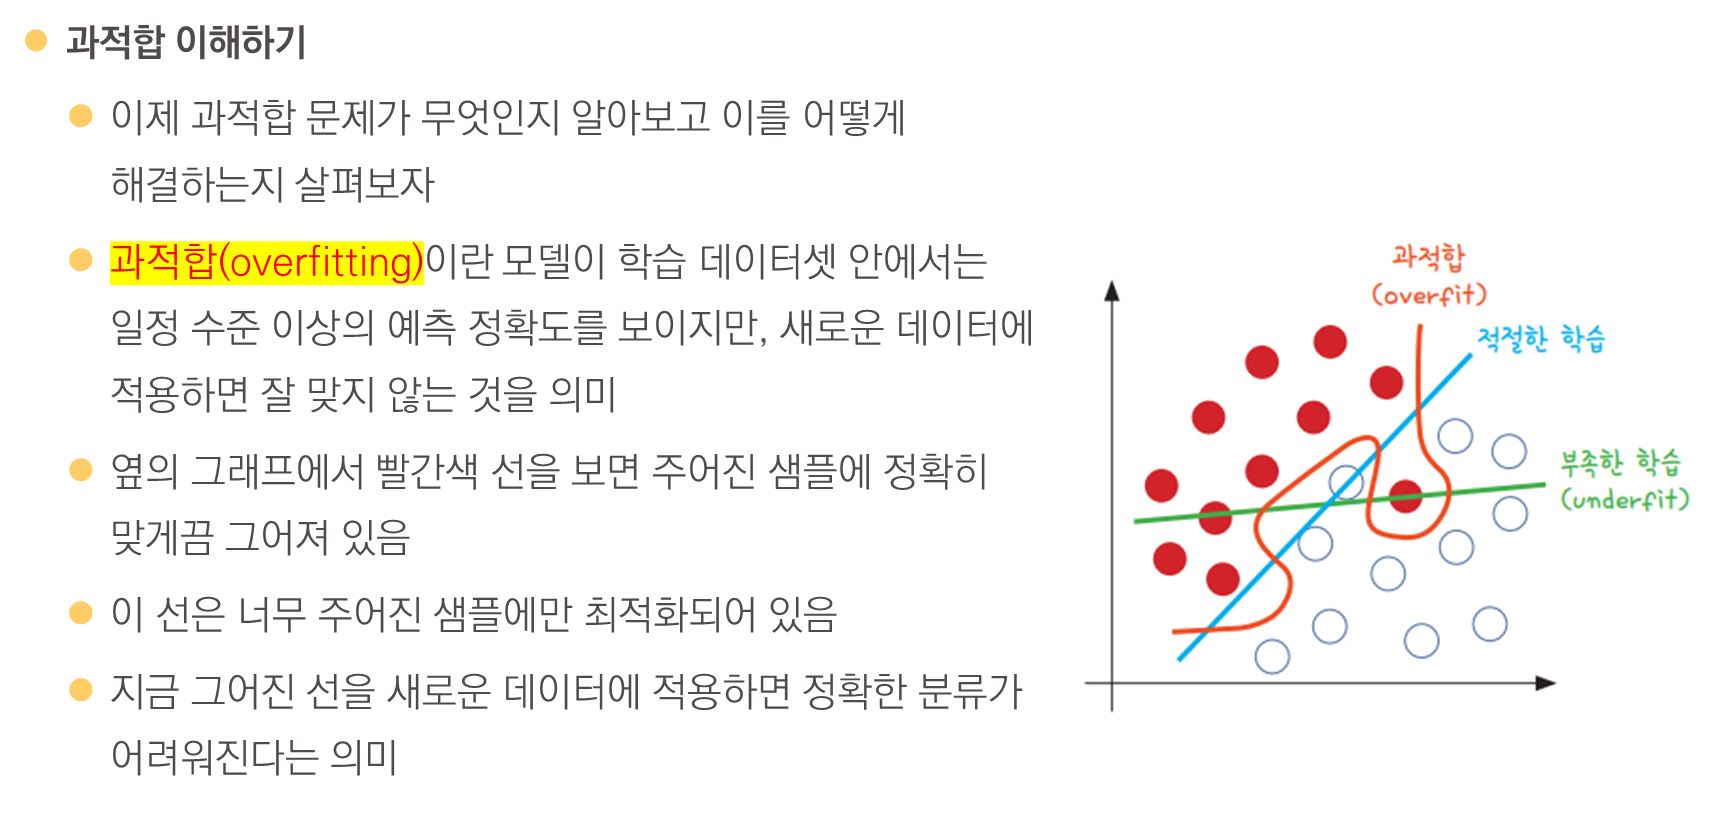

* 과적합은 층이 너무 많거나 변수가 복잡해서 발생하기도 하고 테스트셋과 학습셋이 중복될 때 생기기도 함
* 특히 딥러닝은 학습 단계에서 입력층, 은닉층, 출력층의 노드들에 상당히 많은 변수가 투입
* 딥러닝을 진행하는 동안 과적합에 빠지지 않게 늘 주의해야 함


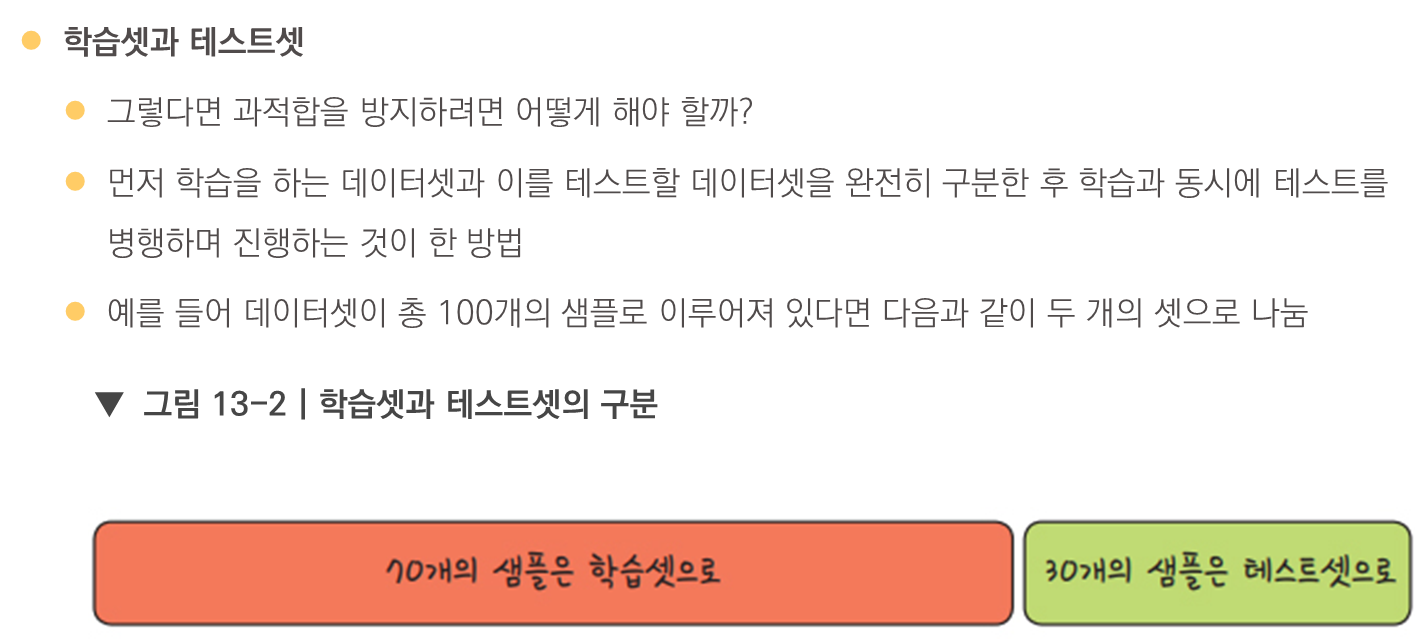

* model.fit에서 validata_data를 지정해주면 history에 검증데이터 셋에 대한 `"val_loss"`와 `"val_accuracy"`가 추가로 출력된다.

In [20]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. 데이터 생성 (0부터 9까지)
X = np.arange(10).reshape(-1, 1) # 2차원 배열 형태 (Feature)
y = np.arange(10)                # 1차원 배열 형태 (Target)

print("=== 분할 전 데이터 ===")
print(f"X (전체): \n{X}")
print(f"y (전체): {y}")
print("-" * 30)


=== 분할 전 데이터 ===
X (전체): 
[[0]
 [1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]
 [9]]
y (전체): [0 1 2 3 4 5 6 7 8 9]
------------------------------


In [21]:

# 2. 데이터 분할 (Train: 80%, Test: 20%)
# test_size=0.2 : 테스트 데이터 비율
# random_state=42 : 난수 시드 고정 (재현 가능성 확보)
# shuffle=True : 데이터를 무작위로 섞음 (기본값)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# X_train, X_test, y_train, y_test = train_test_split(
#   X, y, test_size=0.2, random_state=100, shuffle=True
# )

# 3. 결과 확인
print("=== 분할 후 데이터 (Shuffle 적용됨) ===")
print(f"X_train (학습용 8개): {X_train.flatten()}")
print(f"y_train (학습 정답): {y_train}")
print(f"X_test  (평가용 2개): {X_test.flatten()}")
print(f"y_test  (평가 정답): {y_test}")

=== 분할 후 데이터 (Shuffle 적용됨) ===
X_train (학습용 8개): [1 9 8 5 3 7 0 6]
y_train (학습 정답): [1 9 8 5 3 7 0 6]
X_test  (평가용 2개): [2 4]
y_test  (평가 정답): [2 4]


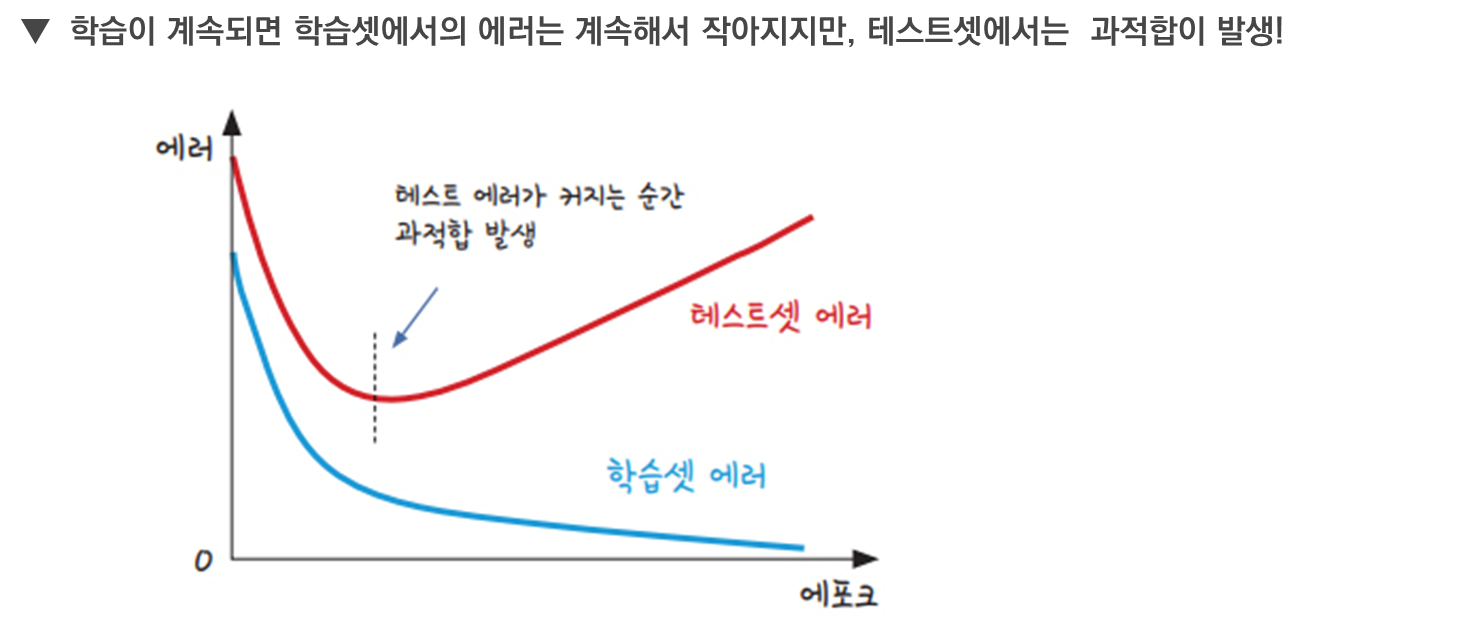

* 학습을 진행해도 테스트 결과가 더 이상 좋아지지 않는 지점에서 학습을 멈추어야 함
* 이때 학습 정도가 가장 적절한 것으로 볼 수 있음


In [22]:
##########################################################
# 13-3 학습셋과 테스트셋 (코드13-2 초음파 광물 예측)
##########################################################
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as  plt
import pandas as pd
import numpy as np

# 데이터 읽기
df_sonar = pd.read_csv('./data/sonar.csv', header=None) # 첫번째 줄이 header가 안되도록

X = df_sonar.iloc[:, :-1].values
Y = df_sonar.iloc[:, -1].values

# M->0 초음파 광석(minaral), R->1 일반광물 : 숫자로 인코딩(0, 1)
e = LabelEncoder()
e.fit(Y)  # Y데이터를 문자에서 정수로 인코딩 수행
Y_encoded = e.transform(Y)

# 학습셋과 테스트셋의 구분
seed = 0
X_train, X_test, Y_train, Y_test = train_test_split(X, Y_encoded, test_size=0.3, random_state=seed)

model = Sequential()
model.add(Dense(24, input_dim=60, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

hist = model.fit(X_train, Y_train, epochs=200, batch_size=5,
                 validation_data=(X_test, Y_test))    # validation_data:학습과정에서 매epoch마다 검증데이터 사용


Epoch 1/200
29/29 [==============================] - 1s 12ms/step - loss: 0.6966 - accuracy: 0.4759 - val_loss: 0.6914 - val_accuracy: 0.5556
Epoch 2/200
29/29 [==============================] - 0s 5ms/step - loss: 0.6844 - accuracy: 0.5862 - val_loss: 0.6760 - val_accuracy: 0.5397
Epoch 3/200
29/29 [==============================] - 0s 5ms/step - loss: 0.6718 - accuracy: 0.5586 - val_loss: 0.6598 - val_accuracy: 0.5556
Epoch 4/200
29/29 [==============================] - 0s 8ms/step - loss: 0.6607 - accuracy: 0.5586 - val_loss: 0.6490 - val_accuracy: 0.5556
Epoch 5/200
29/29 [==============================] - 0s 5ms/step - loss: 0.6470 - accuracy: 0.6552 - val_loss: 0.6391 - val_accuracy: 0.5873
Epoch 6/200
29/29 [==============================] - 0s 5ms/step - loss: 0.6324 - accuracy: 0.6759 - val_loss: 0.6272 - val_accuracy: 0.6984
Epoch 7/200
29/29 [==============================] - 0s 5ms/step - loss: 0.6130 - accuracy: 0.6897 - val_loss: 0.6063 - val_accuracy: 0.7460
Epoch 8/200


## 모델 검증하기

In [44]:
# 학습셋으로 모델 검증 
print("\n Train Accuracy: %.4f" % (model.evaluate(X_train, Y_train) [1]))

# 테스트셋에 모델 적용 
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, Y_test) [1]))

5/5 [==============================] - 0s 2ms/step - loss: 0.0076 - accuracy: 1.0000

 Train Accuracy: 1.0000
2/2 [==============================] - 0s 2ms/step - loss: 0.8715 - accuracy: 0.7778

 Test Accuracy: 0.7778


위의 결과를 보면, Train set와  Test set의 정확도 차이가 1.0과 0.79로 차이가 큰 것을 볼 수 있다.  
### 다시 그래프로 그려보면

In [45]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [46]:
import pandas as pd
pd.DataFrame(hist.history)

,loss,accuracy,val_loss,val_accuracy
0,0.696551,0.475862,0.691404,0.555556
1,0.684403,0.586207,0.675980,0.539683
2,0.671796,0.558621,0.659763,0.555556
3,0.660747,0.558621,0.648993,0.555556
4,0.646963,0.655172,0.639102,0.587302
...,...,...,...,...
195,0.008784,1.000000,0.814608,0.809524
196,0.010944,1.000000,0.838315,0.777778
197,0.008787,1.000000,0.879504,0.793651
198,0.009059,1.000000,0.841003,0.809524


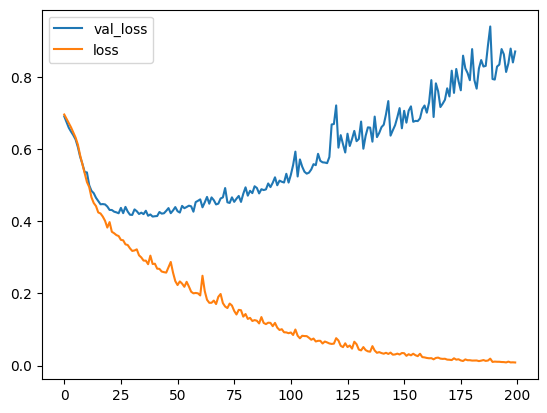

In [47]:
## loss와 val_loss를 하나의 평면에 플롯
plt.plot(hist.history['val_loss'], label='val_loss')
plt.plot(hist.history['loss'], label='loss')
plt.legend()
plt.show()

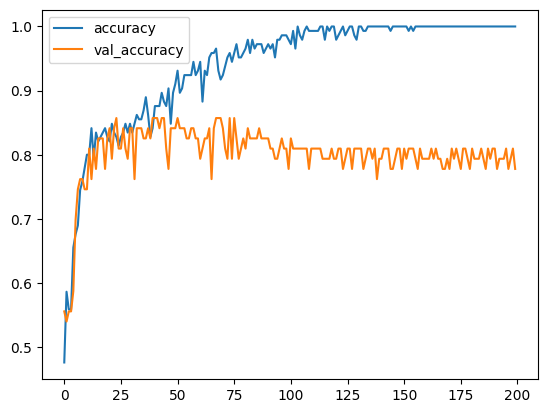

In [26]:
## accuracy와 val_accuracy를 하나의 평면에 plot
plt.plot(hist.history['accuracy'], label='accuracy')
plt.plot(hist.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

In [27]:
df_history = pd.DataFrame(hist.history)

<Axes: >

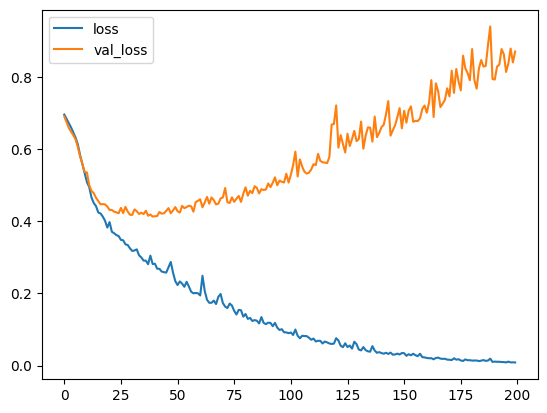

In [28]:
## Pandas DataFrame으로 시각화
df_history[['loss', 'val_loss']].plot()

<Axes: >

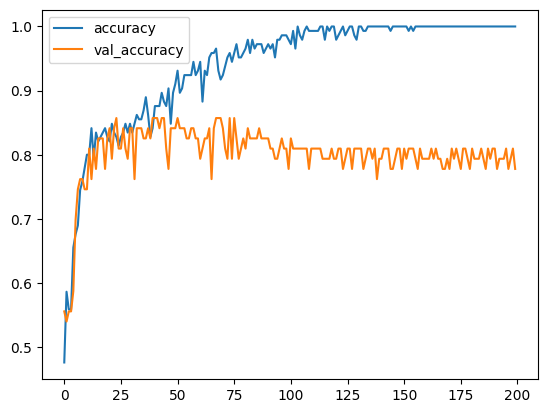

In [29]:
df_history[['accuracy', 'val_accuracy']].plot()

In [30]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 24)                1464      
                                                                 
 dense_9 (Dense)             (None, 10)                250       
                                                                 
 dense_10 (Dense)            (None, 1)                 11        
                                                                 
Total params: 1,725
Trainable params: 1,725
Non-trainable params: 0
_________________________________________________________________


### 모델 저장하기
| 항목               | HDF5 형식 (`.h5`, `.hdf5`)            | Keras 형식 (`.keras`)                       |
|--------------------|----------------------------------------|---------------------------------------------|
| 전체 명칭          | Hierarchical Data Format version 5     | Keras Native Format                         |
| 기반 구조          | HDF5 바이너리 포맷                     | TensorFlow SavedModel 기반 + Zip 구조      |
| 사용 시기          | TensorFlow/Keras 초기부터 사용         | TensorFlow 2.11 이상부터 권장               |
| 모델 정보 저장     | 모델 구조, 가중치, 옵티마이저 등       | 동일 + 추가 메타데이터 확장 가능           |
| 사용자 정의 객체   | 제한적 지원                            | 더 강력한 지원 (사용자 정의 레이어 등)     |
| 확장성             | 낮음                                   | 높음 (향후 기능 확장 고려)                 |
| 불러오기 방식      | `keras.models.load_model()` 사용        | 동일 (확장자 인식 기반 자동 처리)          |
| 권장 여부          | X : 과거 형식 (Legacy)                   | O : 현재 및 향후 권장                         |


In [31]:
model.save('./data/sonar_model.hdf5')  # hdf5 또는  h5 파일로 저장한다. ()
model.save('./data/sonar_model.keras')  # keras 확장자로 변경 2024. (Tensorflow 2.11 이상에서 도입)

In [48]:
type(model)

keras.engine.sequential.Sequential

### 모델 지우기

In [49]:
# del model

In [50]:
# type(model)  # Error !!! not defined

 ### 모델 불러오기

In [35]:
from tensorflow.keras.models import load_model

In [36]:
sonar_model = load_model('./data/sonar_model.keras')

In [37]:
sonar_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 24)                1464      
                                                                 
 dense_9 (Dense)             (None, 10)                250       
                                                                 
 dense_10 (Dense)            (None, 1)                 11        
                                                                 
Total params: 1,725
Trainable params: 1,725
Non-trainable params: 0
_________________________________________________________________


In [38]:
X_test.shape

(63, 60)

In [39]:
sonar_model.predict(X_test).round(3).flatten()

2/2 [==============================] - 0s 9ms/step


array([0.449, 0.166, 0.   , 0.999, 0.   , 0.999, 0.021, 0.023, 0.999,
       0.063, 0.983, 0.   , 0.994, 0.013, 0.919, 1.   , 0.   , 1.   ,
       1.   , 1.   , 0.316, 1.   , 0.   , 0.959, 0.719, 0.97 , 0.028,
       0.001, 0.001, 0.   , 1.   , 0.   , 0.   , 1.   , 0.   , 0.001,
       0.   , 0.025, 0.002, 0.524, 0.005, 0.101, 0.024, 0.   , 0.059,
       1.   , 0.013, 0.397, 0.997, 0.024, 0.181, 0.811, 0.   , 0.   ,
       0.   , 1.   , 0.645, 0.   , 0.   , 0.117, 0.055, 0.05 , 1.   ],
      dtype=float32)

In [40]:
(sonar_model.predict(X_test) >= 0.5).astype(int).flatten()

2/2 [==============================] - 0s 4ms/step


array([0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1])

In [41]:
sonar_model.evaluate(X_train, Y_train)

5/5 [==============================] - 0s 2ms/step - loss: 0.0076 - accuracy: 1.0000


[0.007625138387084007, 1.0]

In [42]:
sonar_model.evaluate(X_test, Y_test)

2/2 [==============================] - 0s 5ms/step - loss: 0.8715 - accuracy: 0.7778


[0.8714821934700012, 0.7777777910232544]

In [43]:
## 정확도 계산
(((sonar_model.predict(X_test) >= 0.5) * 1).flatten() == Y_test).mean()

2/2 [==============================] - 0s 6ms/step


0.7777777777777778

### 참고 : Teachable Machine 등 다른 프로그램에서 저장한 h5(hdf5) 모델을 읽어와서 사용할 수 있다.

In [ ]:
### Teachable Machine에서 저장한 모델 읽어 오기 (Tensorflow 2.xx 모델 이상에서는 버전 충돌 할 수 있음: h5 -> tf 2.15 가능)
teachable_model = load_model('C:/data/models/keras_model.h5')
teachable_model.summary()

In [ ]:
teachable_model.compile(loss='softmax',
                        optimizer='adam',
                        metrics=['accuracy'])

In [ ]:
teachable_model.summary()

### [연습문제] IRIS 데이터로 train_test_split을 하여 검증데이터셋을 분리하고, validation_data를 지정하여 학습하게 하여 val_accuracy 와 val_loss를 시각화 하라

In [ ]:
############################################################
# 13-3 과적합 피하기 (4) - IRIS data에 
# - IRIS data에 학습/테스트셋 분리 분석
###########################################################
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import tensorflow as tf

# seed 값 설정
seed = 0

# 데이터 입력
df_iris = pd.read_csv('./data/iris3.csv')
# df_iris = pd.read_csv('../data/iris.csv', 
#                  names = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"])

X = df_iris.iloc[:, 0:4].astype(float).values  # float tensor로 쓸 수 있도록
Y = df_iris.species.values

e = LabelEncoder()  # 라벨 인코더 정의
e.fit(Y)        # Y_obj의 문자데이터를 분석
Y_encoded = e.transform(Y) # 

Y_onehot = tf.keras.utils.to_categorical(Y_encoded) # One Hot Encoding
             # [1, 0, 0], [0, 1, 0], [0, 0, 1] 형태

# 학습셋과 테스트셋의 구분
X_train, X_test, Y_train, Y_test = train_test_split(X, Y_onehot, test_size=0.3, random_state=seed)

## 모델 설계
model = Sequential()
model.add(Dense(10, input_dim=4, activation='relu'))
# model.add(Dense(10, activation='relu'))
model.add(Dense(3, activation='softmax'))  # 다중분류 -> softmax

# 모델 컴파일 > 다중분류 : categorical_crossentropy
model.compile(loss= 'categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# 학습
# hist = model.fit(X_train, Y_train, epochs=200, batch_size=5)
hist = model.fit(X_train, Y_train, epochs=200, batch_size=5,
                validation_data=(X_test, Y_test))

In [ ]:
# 학습셋 Accuracy 계산
print("\n Train Accuracy: %.4f" % (model.evaluate(X_train, Y_train)[1]))

# 테스트셋 Accuracy 계산 
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, Y_test)[1]))


In [ ]:

## hist.history를 pandas data frame으로 만들어서 시각화
df_history = pd.DataFrame(hist.history)
df_history[['loss', 'val_loss']].plot()

In [ ]:
df_history[['accuracy', 'val_accuracy']].plot()  # 정확도 그래프

In [ ]:
## 모델 저장
model.save('./data/iris_model.keras')

## k겹 교차검증

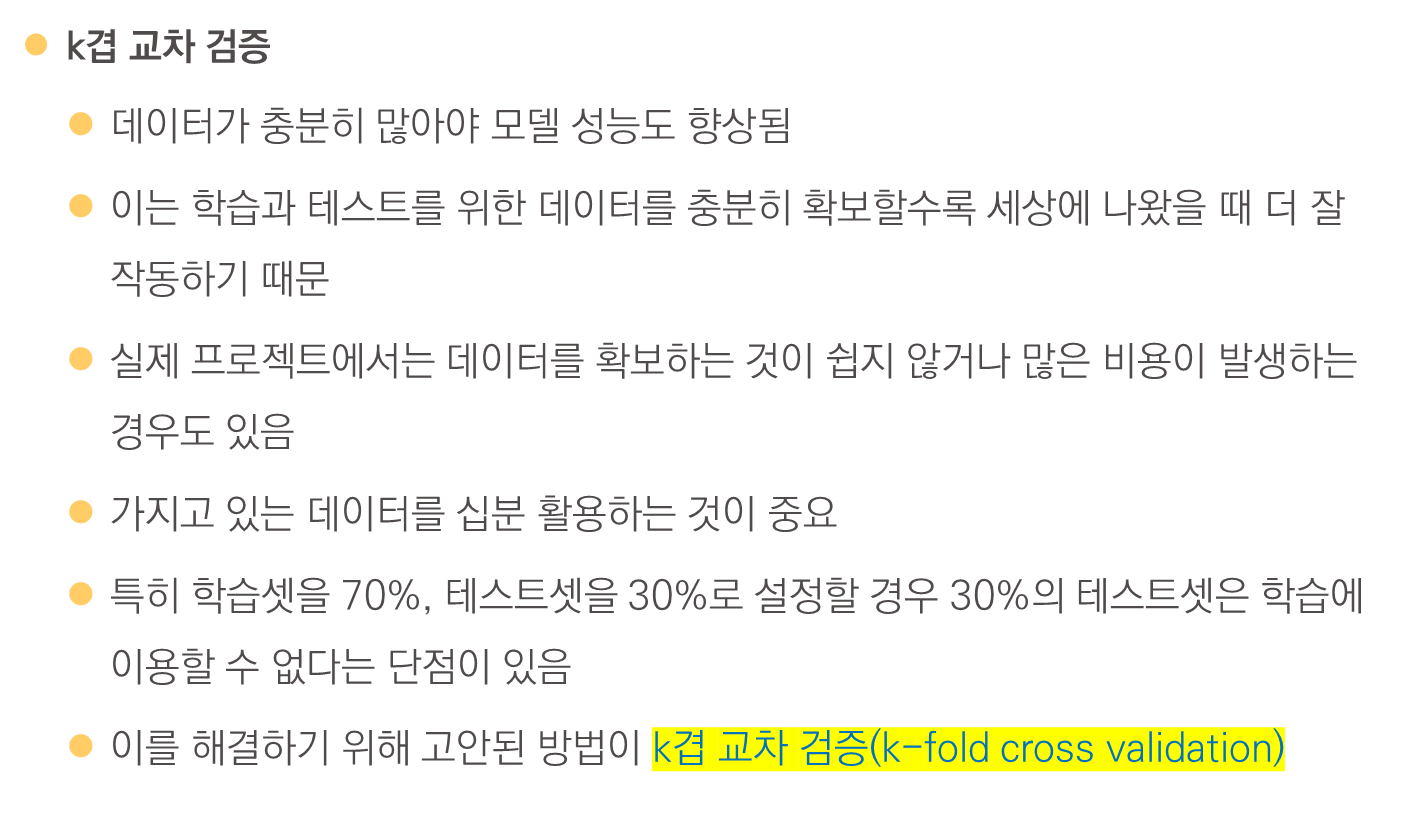
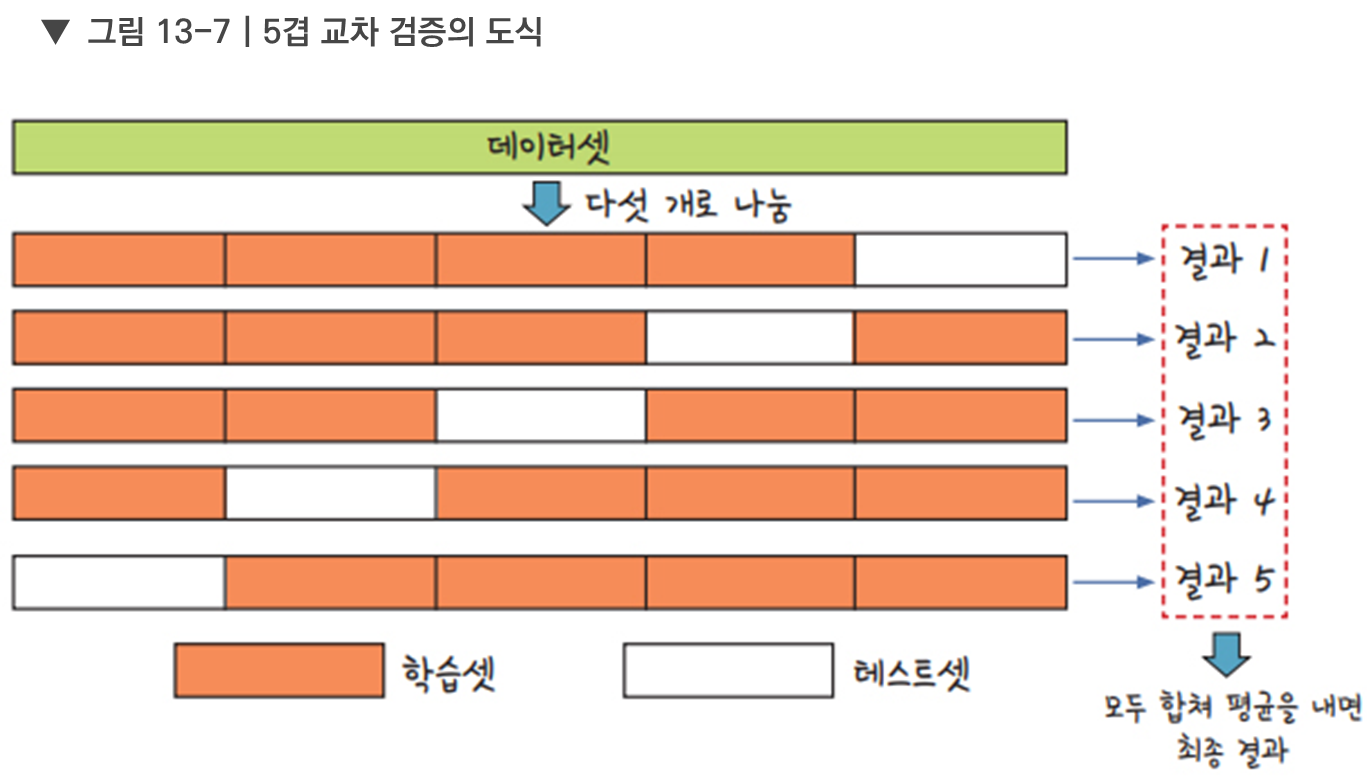

In [51]:
import numpy as np
from sklearn.model_selection import KFold

# 1. 샘플 데이터 생성 (0~9)
X = np.arange(100, 200, 10)
y = np.arange(200, 300, 10)

# 2. KFold 객체 생성 (5개의 폴드)
kf = KFold(n_splits=5, shuffle=True) # , random_state=42)

print(f"전체 데이터: {X}")
print("-" * 50)

전체 데이터: [100 110 120 130 140 150 160 170 180 190]
--------------------------------------------------


In [52]:
list(kf.split(X))

[(array([0, 2, 3, 4, 5, 6, 7, 8]), array([1, 9])),
 (array([0, 1, 2, 3, 4, 6, 7, 9]), array([5, 8])),
 (array([0, 1, 3, 4, 5, 7, 8, 9]), array([2, 6])),
 (array([1, 2, 4, 5, 6, 7, 8, 9]), array([0, 3])),
 (array([0, 1, 2, 3, 5, 6, 8, 9]), array([4, 7]))]

In [53]:
# 3. K-Fold 반복 수행
fold_idx = 1
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    
    print(f"[Fold {fold_idx}]")
    print(f"  - 학습 데이터 index: {train_index} -> 데이터: {X_train}")
    print(f"  - 검증 데이터 index: {test_index} -> 데이터: {X_test}")
    fold_idx += 1

# 실제 모델링에서는 각 Fold의 성능 점수를 리스트에 담아 평균을 냅니다.

[Fold 1]
  - 학습 데이터 index: [0 2 3 4 5 6 7 9] -> 데이터: [100 120 130 140 150 160 170 190]
  - 검증 데이터 index: [1 8] -> 데이터: [110 180]
[Fold 2]
  - 학습 데이터 index: [1 2 3 4 5 6 8 9] -> 데이터: [110 120 130 140 150 160 180 190]
  - 검증 데이터 index: [0 7] -> 데이터: [100 170]
[Fold 3]
  - 학습 데이터 index: [0 1 3 4 6 7 8 9] -> 데이터: [100 110 130 140 160 170 180 190]
  - 검증 데이터 index: [2 5] -> 데이터: [120 150]
[Fold 4]
  - 학습 데이터 index: [0 1 2 4 5 6 7 8] -> 데이터: [100 110 120 140 150 160 170 180]
  - 검증 데이터 index: [3 9] -> 데이터: [130 190]
[Fold 5]
  - 학습 데이터 index: [0 1 2 3 5 7 8 9] -> 데이터: [100 110 120 130 150 170 180 190]
  - 검증 데이터 index: [4 6] -> 데이터: [140 160]


* K겹 교차 검증 전체 코드

In [54]:
###########################################################
# k-Fold Cross Validation
###########################################################
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

import pandas as pd

# 데이터를 입력합니다.
df = pd.read_csv('./data/sonar3.csv', header=None)

# 음파 관련 속성을 X로, 광물의 종류를 y로 저장합니다.
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

#몇 겹으로 나눌 것인지를 정합니다. 
k=5

#KFold 함수를 불러옵니다. 분할하기 전에 샘플이 치우치지 않도록 섞어 줍니다.
kfold = KFold(n_splits=k, shuffle=True)

#정확도가 채워질 빈 리스트를 준비합니다.
acc_score, history_list = [], []

def model_fn():
    model = Sequential() #딥러닝 모델의 구조를 시작합니다.
    model.add(Dense(24, input_dim=60, activation='relu'))
    model.add(Dense(10, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    return model

#K겹 교차 검증을 이용해 k번의 학습을 실행합니다. 
for train_index , test_index in kfold.split(X):  # for문에 의해서 k번 반복합니다. spilt()에 의해 k개의 학습셋, 테스트셋으로 분리됩니다.
    X_train , X_test = X.iloc[train_index,:], X.iloc[test_index,:]  
    y_train , y_test = y.iloc[train_index], y.iloc[test_index]

    model1 = model_fn()
    model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    history = model1.fit(X_train, y_train, epochs=200, batch_size=10, verbose=0)   # verbose=0 으로 학습과정 출력 생략
    
    accuracy = model1.evaluate(X_test, y_test)[1]  #정확도를 구합니다.
    acc_score.append(accuracy)  #정확도 리스트에 저장합니다.
    history_list.append(history.history)  # 딕셔너리를 빈 리스트에 append

#k번 실시된 정확도의 평균을 구합니다.
avg_acc_score = sum(acc_score)/k

#결과를 출력합니다.
print('정확도:', acc_score)
print('정확도 평균:', avg_acc_score)

2/2 [==============================] - 0s 4ms/step - loss: 0.7347 - accuracy: 0.8293
정확도: [0.8095238208770752, 0.738095223903656, 0.8809523582458496, 0.9268292784690857, 0.8292682766914368]
정확도 평균: 0.8369337916374207


In [56]:
len(history_list)

5

In [57]:
acc_score

[0.8095238208770752,
 0.738095223903656,
 0.8809523582458496,
 0.9268292784690857,
 0.8292682766914368]

In [58]:
history_list

[{'loss': [0.705138087272644,
   0.6887460350990295,
   0.6827256679534912,
   0.6768253445625305,
   0.6714348793029785,
   0.6660940051078796,
   0.6606647372245789,
   0.6525024771690369,
   0.6402950286865234,
   0.6281061768531799,
   0.6177182197570801,
   0.6077255606651306,
   0.5898541808128357,
   0.5790131092071533,
   0.5601794123649597,
   0.5474739670753479,
   0.5346343517303467,
   0.5182263255119324,
   0.5041083097457886,
   0.4907115399837494,
   0.4813224673271179,
   0.46964332461357117,
   0.46081721782684326,
   0.4466567039489746,
   0.43362122774124146,
   0.42756468057632446,
   0.42223069071769714,
   0.42253562808036804,
   0.4047389626502991,
   0.39963796734809875,
   0.38934892416000366,
   0.3885904848575592,
   0.3831959366798401,
   0.37369072437286377,
   0.3689879775047302,
   0.3697311282157898,
   0.375893771648407,
   0.36165499687194824,
   0.35465264320373535,
   0.345522403717041,
   0.343376100063324,
   0.3417789936065674,
   0.34012725949287